In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


### Einladen und Entfernen unnötiger Spalten

In [2]:
df = pd.read_csv('COVID-19.csv')
df.head()

,Country,Other names,ISO 3166-1 alpha-3 CODE,Population,Continent,Total Cases,Total Deaths,Tot Cases//1M pop,Tot Deaths/1M pop,Death percentage
0,Afghanistan,Afghanistan,AFG,40462186,Asia,177827,7671,4395,190,4.313743
1,Albania,Albania,ALB,2872296,Europe,273870,3492,95349,1216,1.275058
2,Algeria,Algeria,DZA,45236699,Africa,265691,6874,5873,152,2.587216
3,Andorra,Andorra,AND,77481,Europe,40024,153,516565,1975,0.382271
4,Angola,Angola,AGO,34654212,Africa,99194,1900,2862,55,1.915438


In [3]:
df.drop("Other names", axis=1, inplace=True)
df.drop("ISO 3166-1 alpha-3 CODE", axis=1, inplace=True)
df.rename(columns={'Tot\xa0Deaths/1M pop': 'TD1Mpop', 'Tot\xa0Cases//1M pop': 'TC1Mpop'}, inplace=True)
df.head()


,Country,Population,Continent,Total Cases,Total Deaths,TC1Mpop,TD1Mpop,Death percentage
0,Afghanistan,40462186,Asia,177827,7671,4395,190,4.313743
1,Albania,2872296,Europe,273870,3492,95349,1216,1.275058
2,Algeria,45236699,Africa,265691,6874,5873,152,2.587216
3,Andorra,77481,Europe,40024,153,516565,1975,0.382271
4,Angola,34654212,Africa,99194,1900,2862,55,1.915438


### Detaillierte Übersicht 

In [4]:
df

,Country,Population,Continent,Total Cases,Total Deaths,TC1Mpop,TD1Mpop,Death percentage
0,Afghanistan,40462186,Asia,177827,7671,4395,190,4.313743
1,Albania,2872296,Europe,273870,3492,95349,1216,1.275058
2,Algeria,45236699,Africa,265691,6874,5873,152,2.587216
3,Andorra,77481,Europe,40024,153,516565,1975,0.382271
4,Angola,34654212,Africa,99194,1900,2862,55,1.915438
...,...,...,...,...,...,...,...,...
220,Wallis and Futuna,10894,Oceania,454,7,41674,643,1.541850
221,Western Sahara,623031,Africa,10,1,16,2,10.000000
222,Yemen,30975258,Asia,11806,2143,381,69,18.151787
223,Zambia,19284482,Africa,317076,3967,16442,206,1.251120


In [5]:
df.columns

Index(['Country', 'Population', 'Continent', 'Total Cases', 'Total Deaths',
       'TC1Mpop', 'TD1Mpop', 'Death percentage'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           225 non-null    object 
 1   Population        225 non-null    int64  
 2   Continent         225 non-null    object 
 3   Total Cases       225 non-null    int64  
 4   Total Deaths      225 non-null    int64  
 5   TC1Mpop           225 non-null    int64  
 6   TD1Mpop           225 non-null    int64  
 7   Death percentage  225 non-null    float64
dtypes: float64(1), int64(5), object(2)
memory usage: 14.2+ KB


In [7]:
df.isnull().sum(axis = 0)

Country             0
Population          0
Continent           0
Total Cases         0
Total Deaths        0
TC1Mpop             0
TD1Mpop             0
Death percentage    0
dtype: int64

In [8]:
df[df.isnull().sum(axis = 1) > 0]

,Country,Population,Continent,Total Cases,Total Deaths,TC1Mpop,TD1Mpop,Death percentage


### Analysen

In [9]:
df.describe()

,Population,Total Cases,Total Deaths,TC1Mpop,TD1Mpop,Death percentage
count,2.250000e+02,2.250000e+02,2.250000e+02,225.000000,225.000000,225.000000
mean,3.507321e+07,2.184781e+06,2.744813e+04,136900.373333,1096.715556,1.444125
std,1.392418e+08,7.275938e+06,9.689177e+04,145060.340289,1195.715543,1.741728
min,8.050000e+02,1.000000e+00,0.000000e+00,9.000000,0.000000,0.000000
25%,5.665570e+05,2.407100e+04,1.890000e+02,11384.000000,123.000000,0.511291
50%,5.827911e+06,1.639360e+05,1.965000e+03,88987.000000,708.000000,1.036905
75%,2.190585e+07,1.092547e+06,1.366000e+04,223335.000000,1795.000000,1.977017
max,1.439324e+09,8.183905e+07,1.008222e+06,696044.000000,6286.000000,18.151787


array([[<Axes: title={'center': 'Death percentage'}>]], dtype=object)

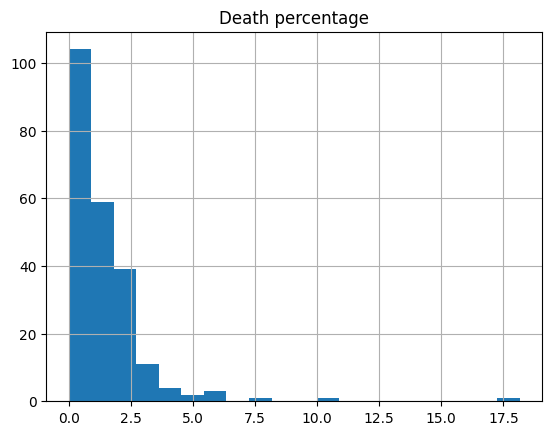

In [10]:
df.hist(column='Death percentage', bins=20)

<Axes: >

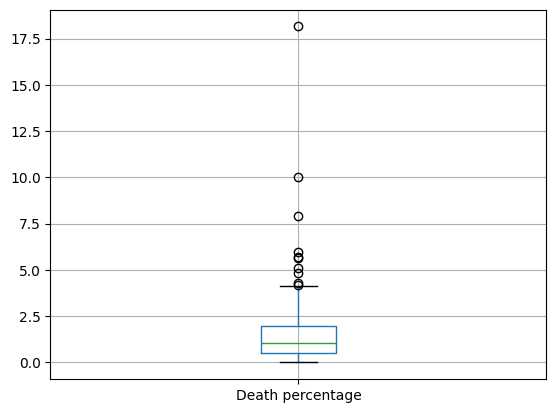

In [11]:
df.boxplot(column='Death percentage')

In [12]:
df[df['Death percentage'] > 5]

,Country,Population,Continent,Total Cases,Total Deaths,TC1Mpop,TD1Mpop,Death percentage
130,Mexico,131303955,Latin America and the Caribbean,5665376,323212,43147,2462,5.705041
158,Peru,33775745,Latin America and the Caribbean,3548559,212328,105062,6286,5.983499
186,Somalia,16668781,Africa,26400,1348,1584,81,5.106061
193,Sudan,45640385,Africa,61955,4907,1357,108,7.920265
197,Syria,18244381,Asia,55711,3144,3054,172,5.643410
221,Western Sahara,623031,Africa,10,1,16,2,10.000000
222,Yemen,30975258,Asia,11806,2143,381,69,18.151787


## Höchste Werte

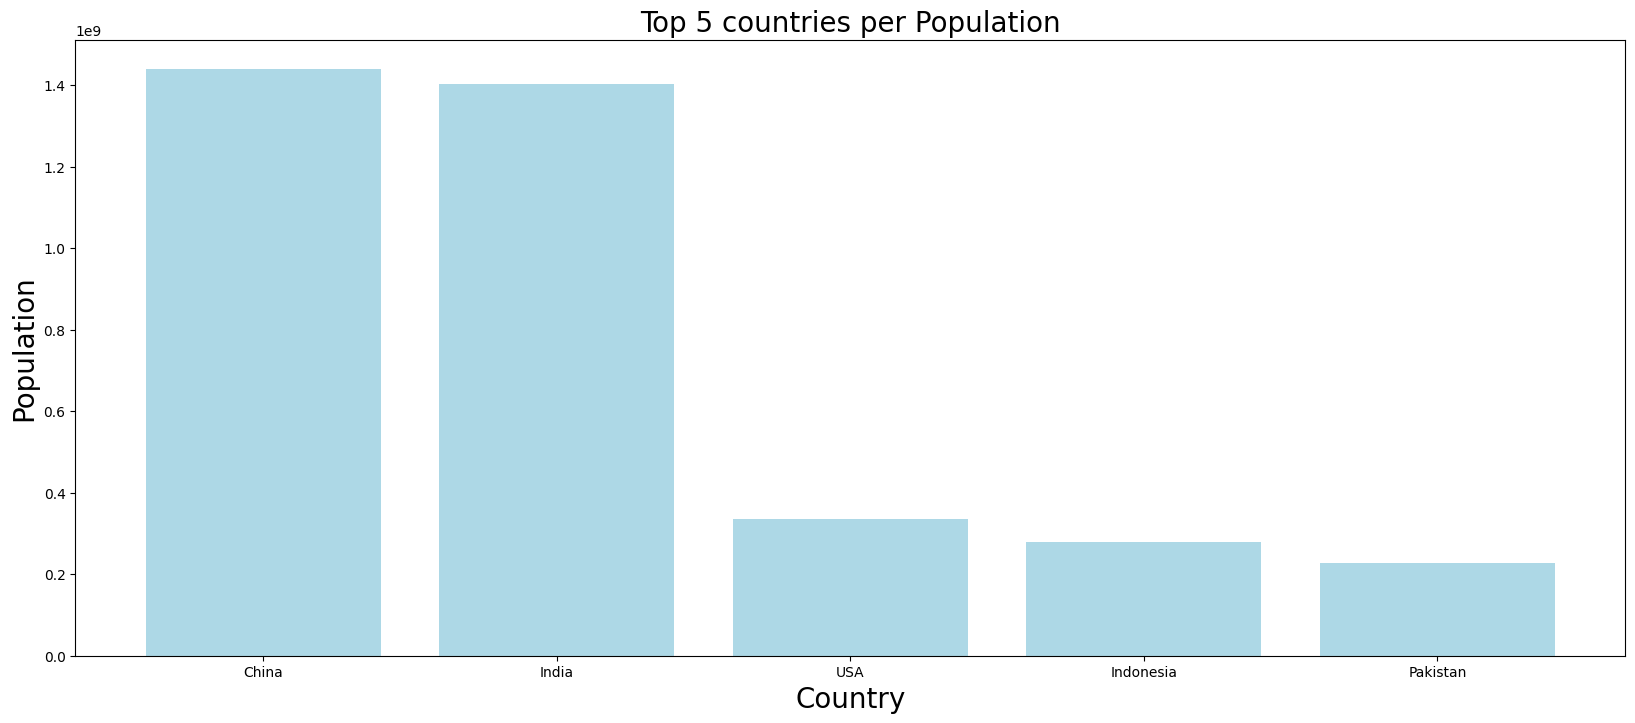

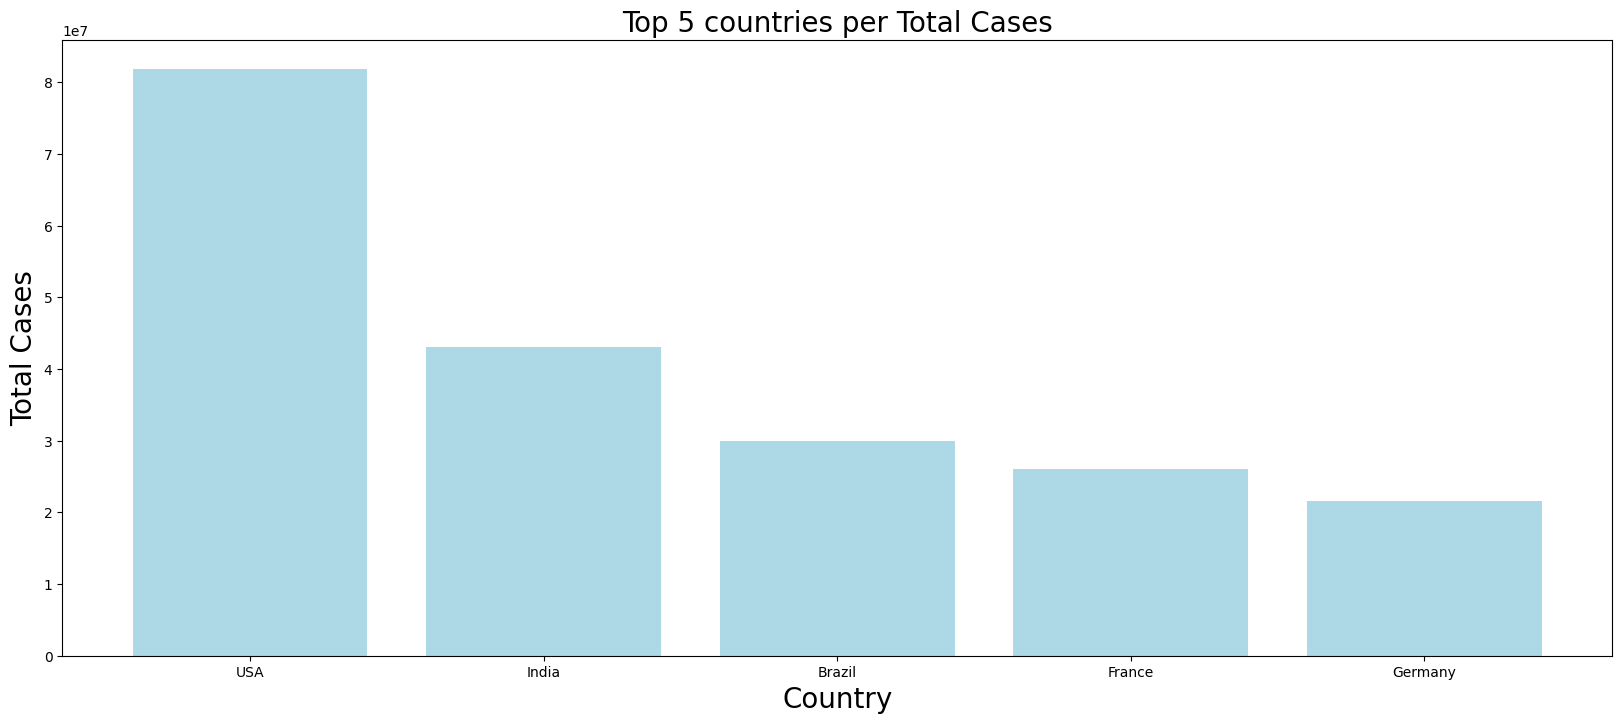

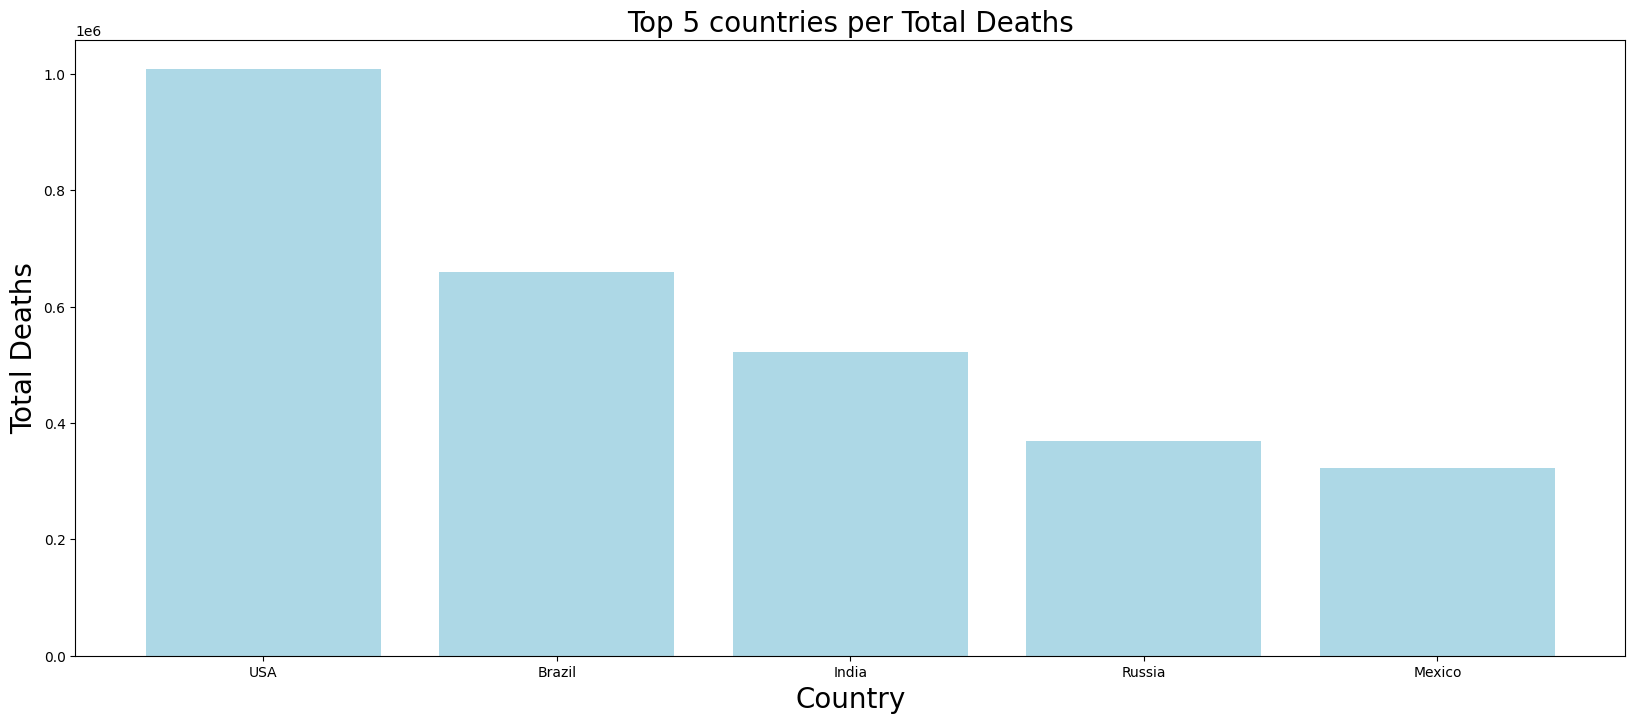

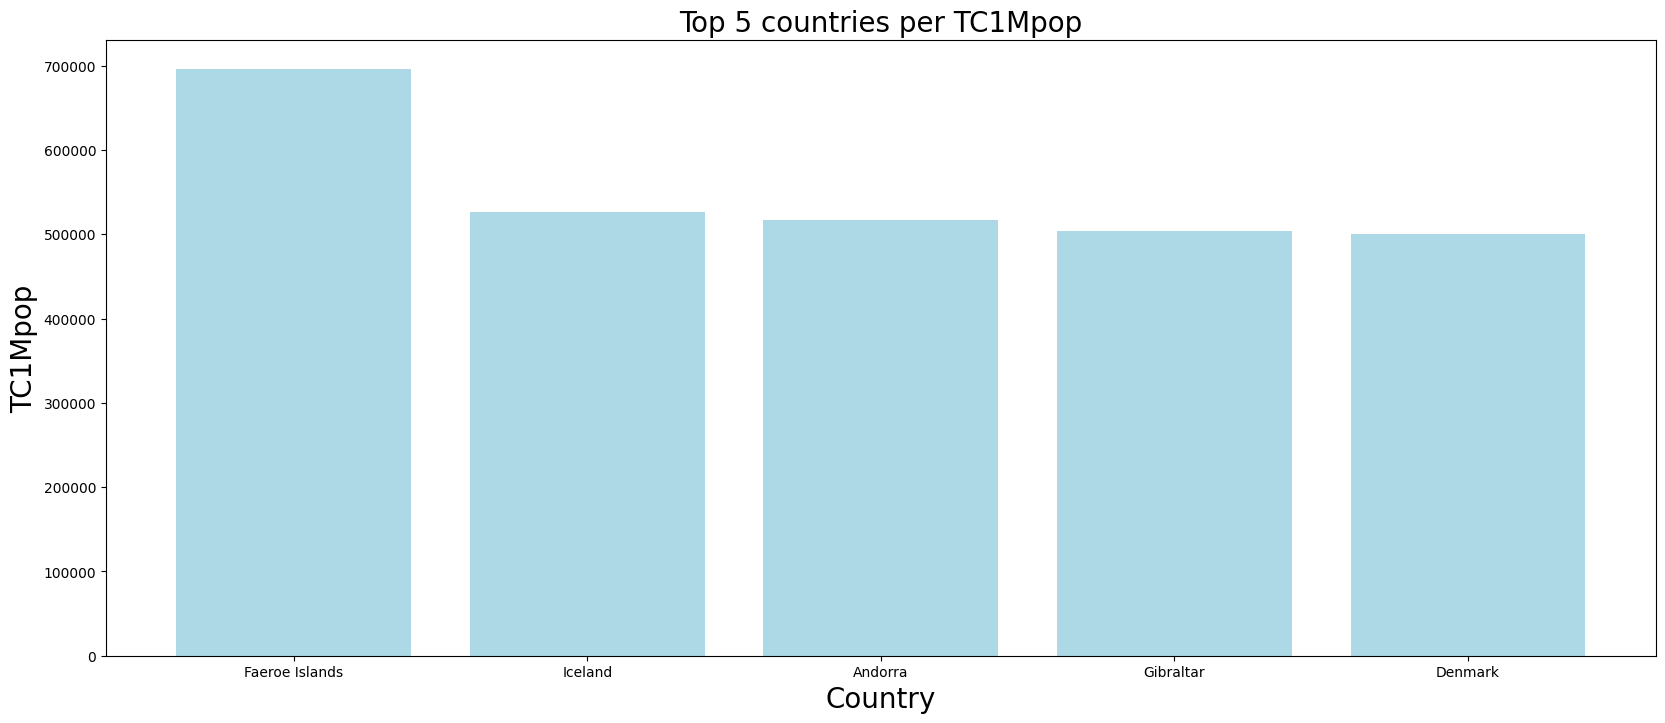

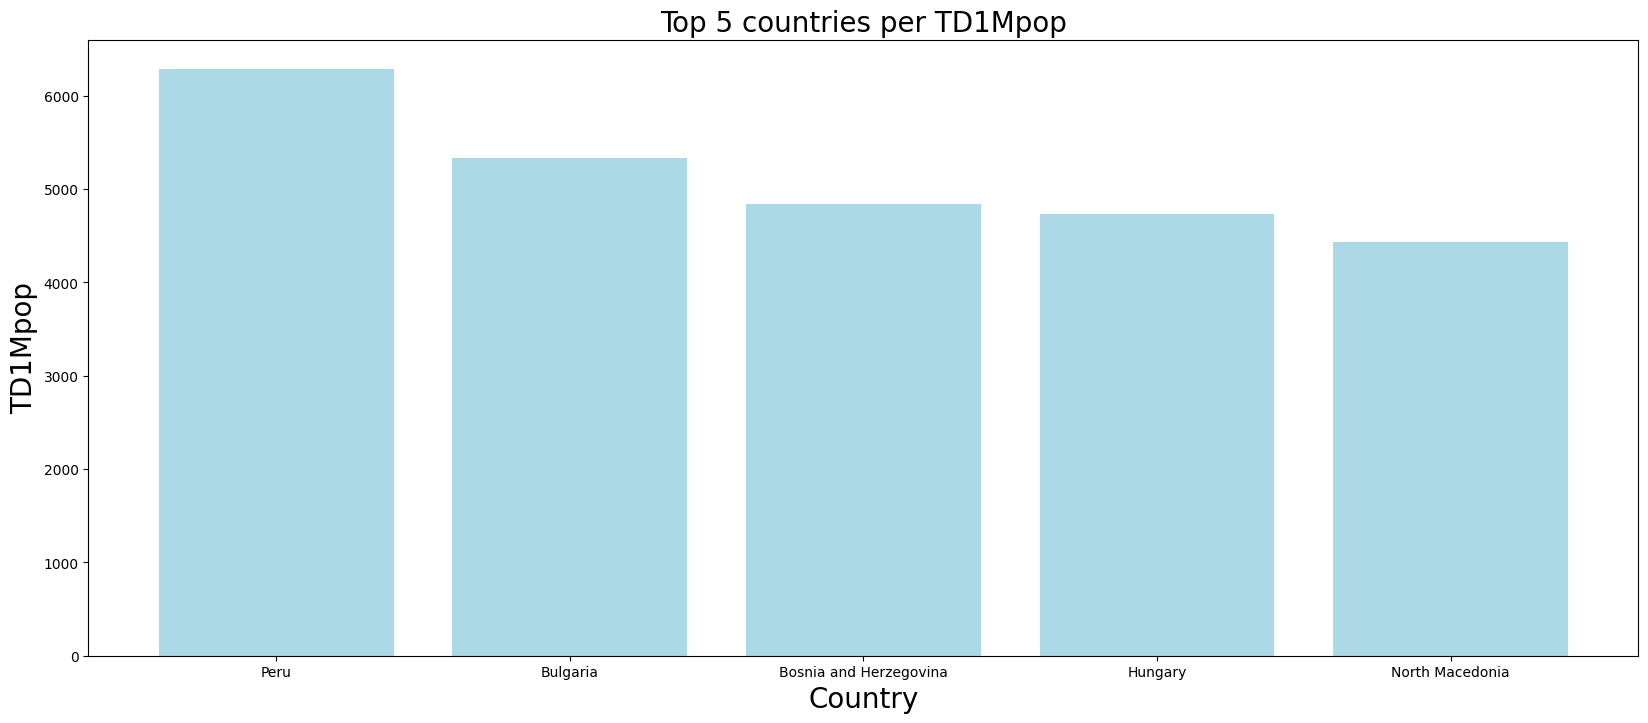

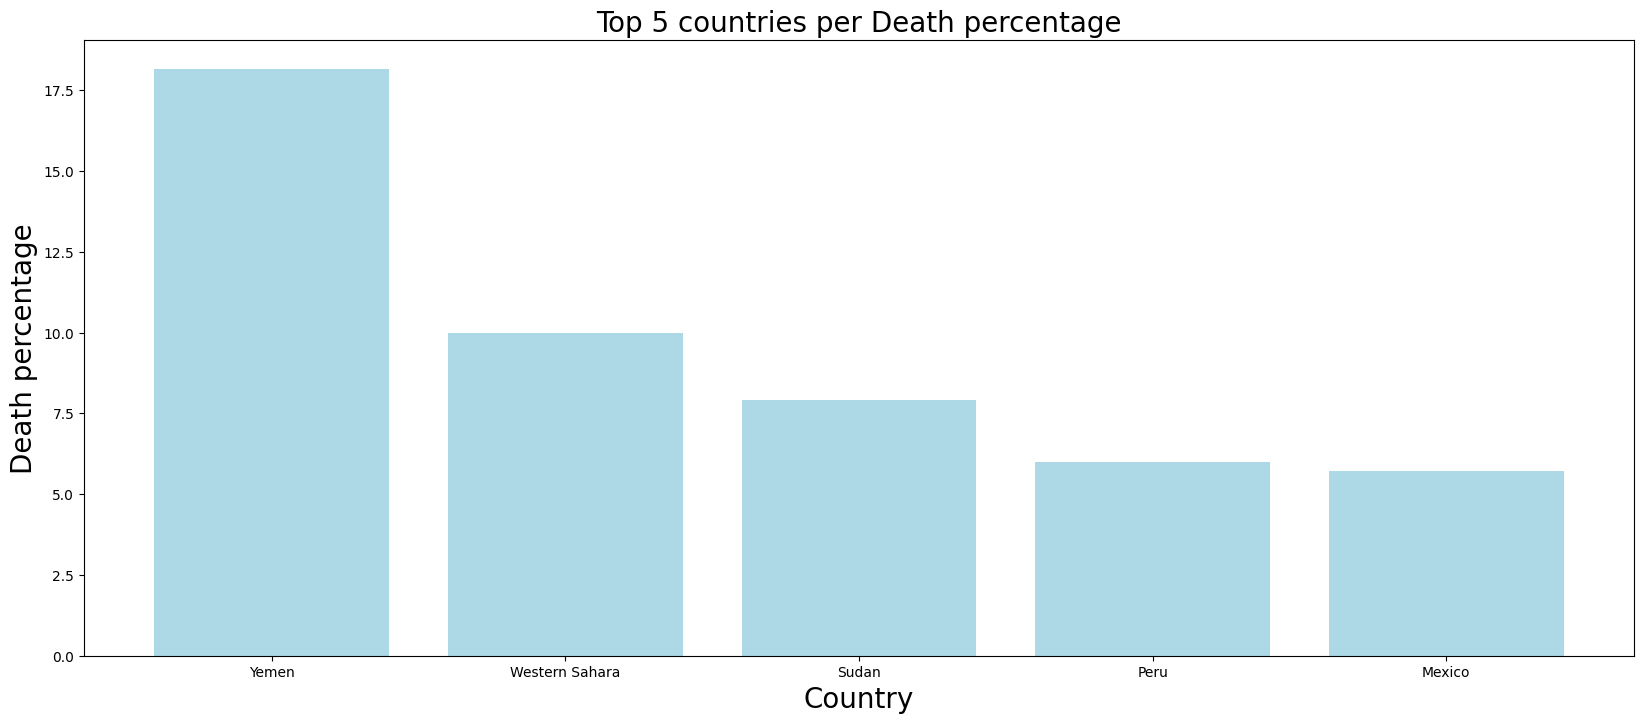

In [13]:
columns = [column for column in df.columns if df[column].dtype != 'object']
for column in columns:
  top5 = df.nlargest(5,column)
  plt.figure(figsize=(20,8))
  plt.bar(top5['Country'], top5[column],color='lightblue',alpha=1)
  plt.ylabel(column, fontsize = 20)
  plt.xlabel("Country", fontsize = 20)
  plt.title(f"Top 5 countries per {column}", fontsize = 20)
  plt.show()

* Diskussion

## Niedrigste Werte

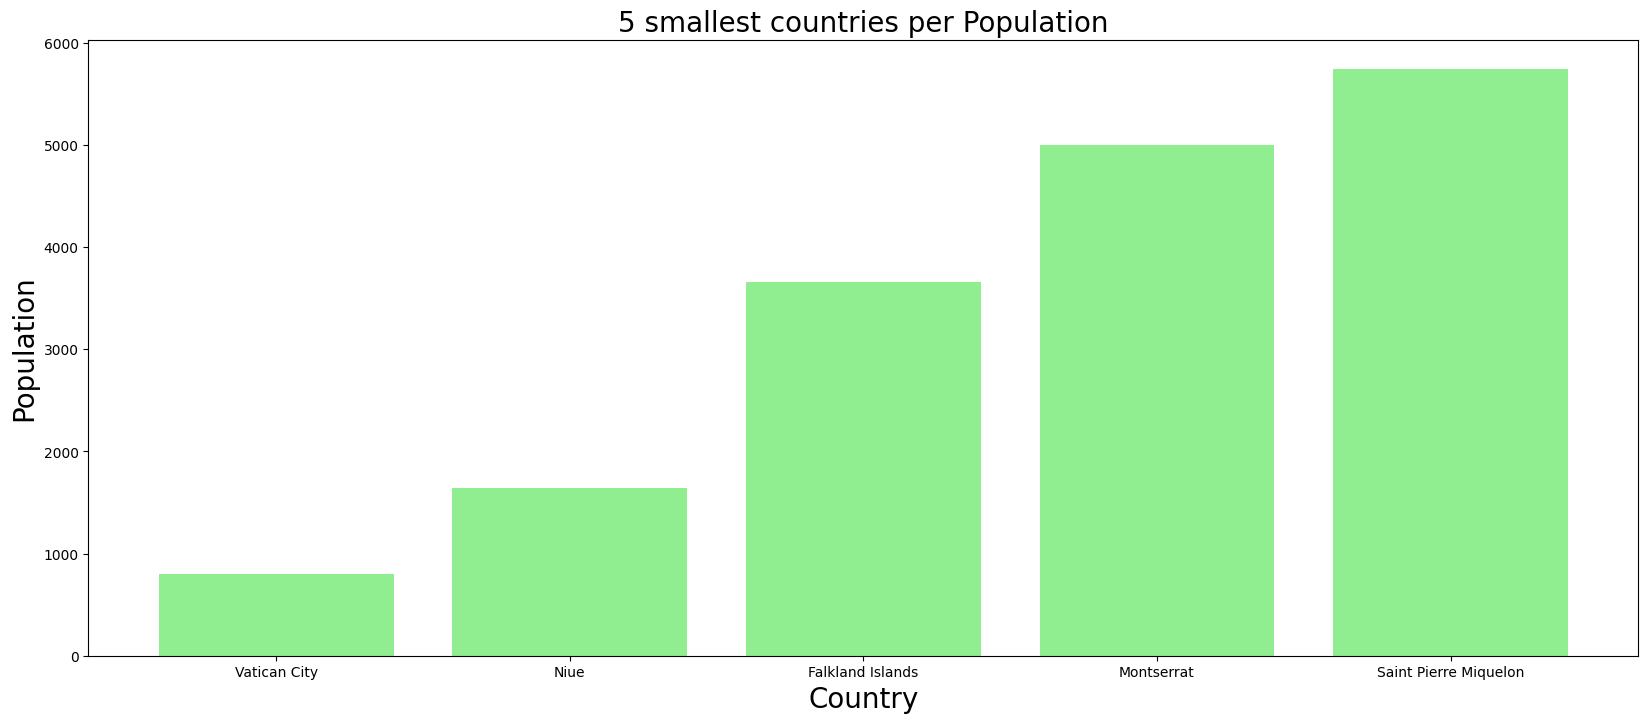

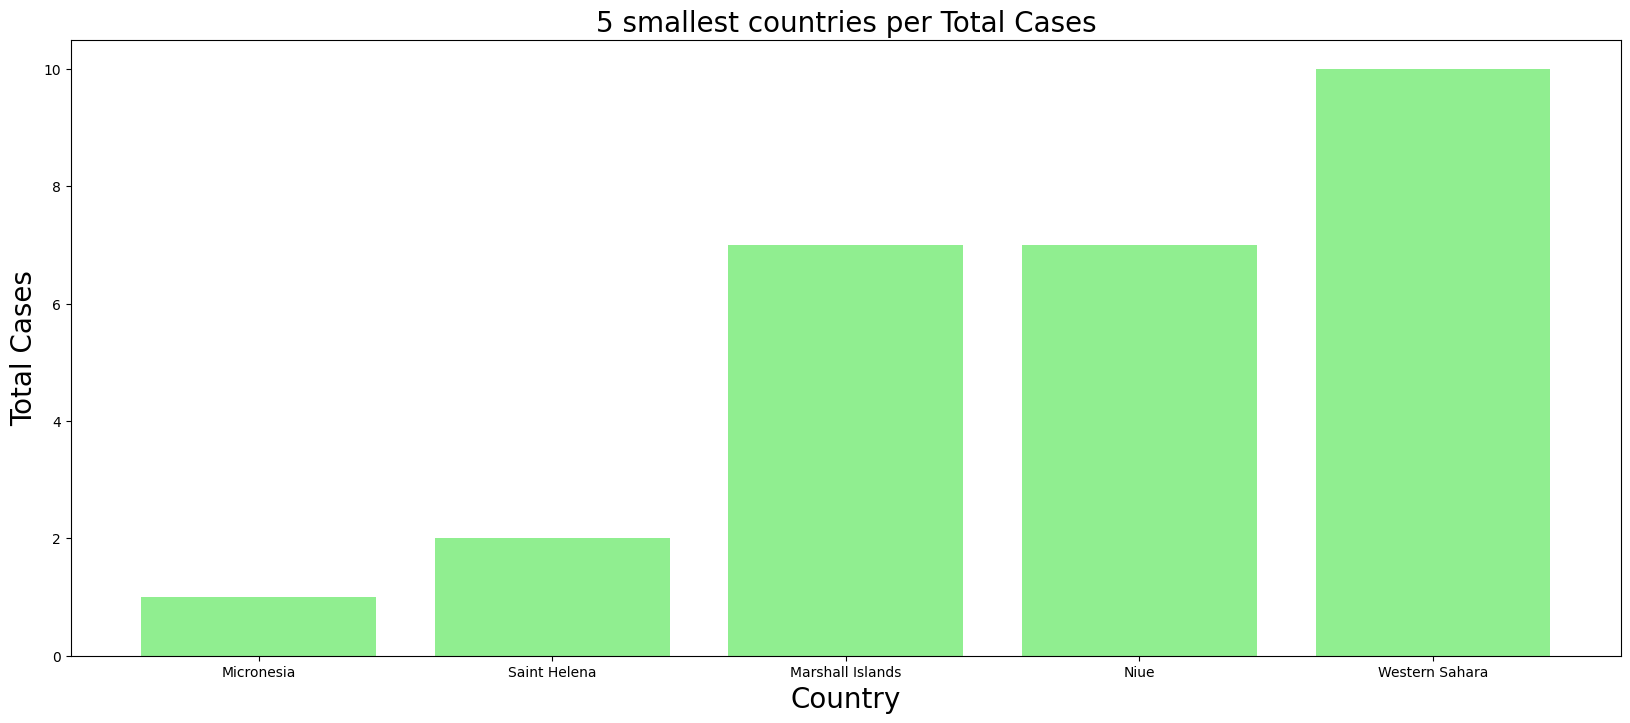

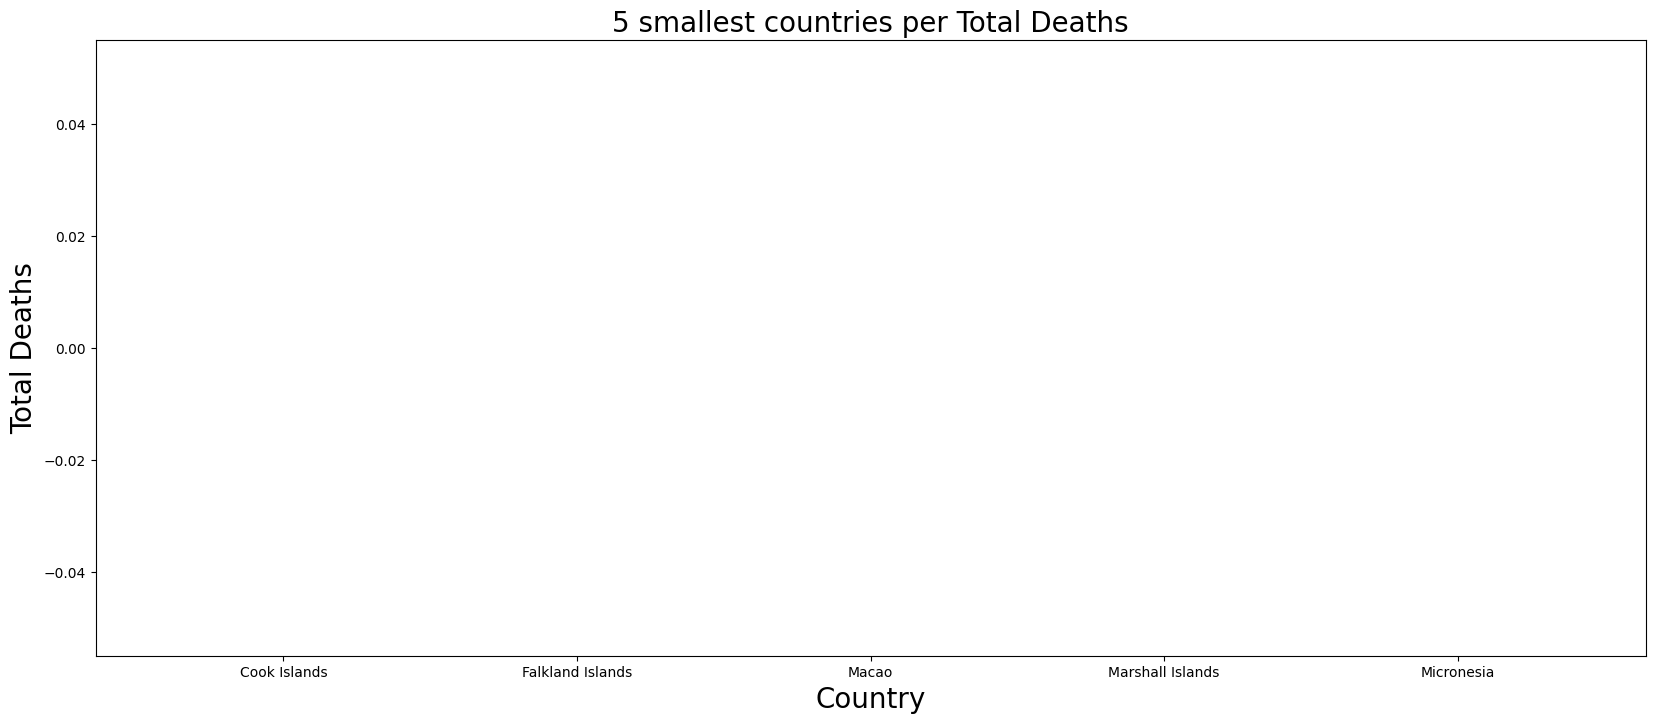

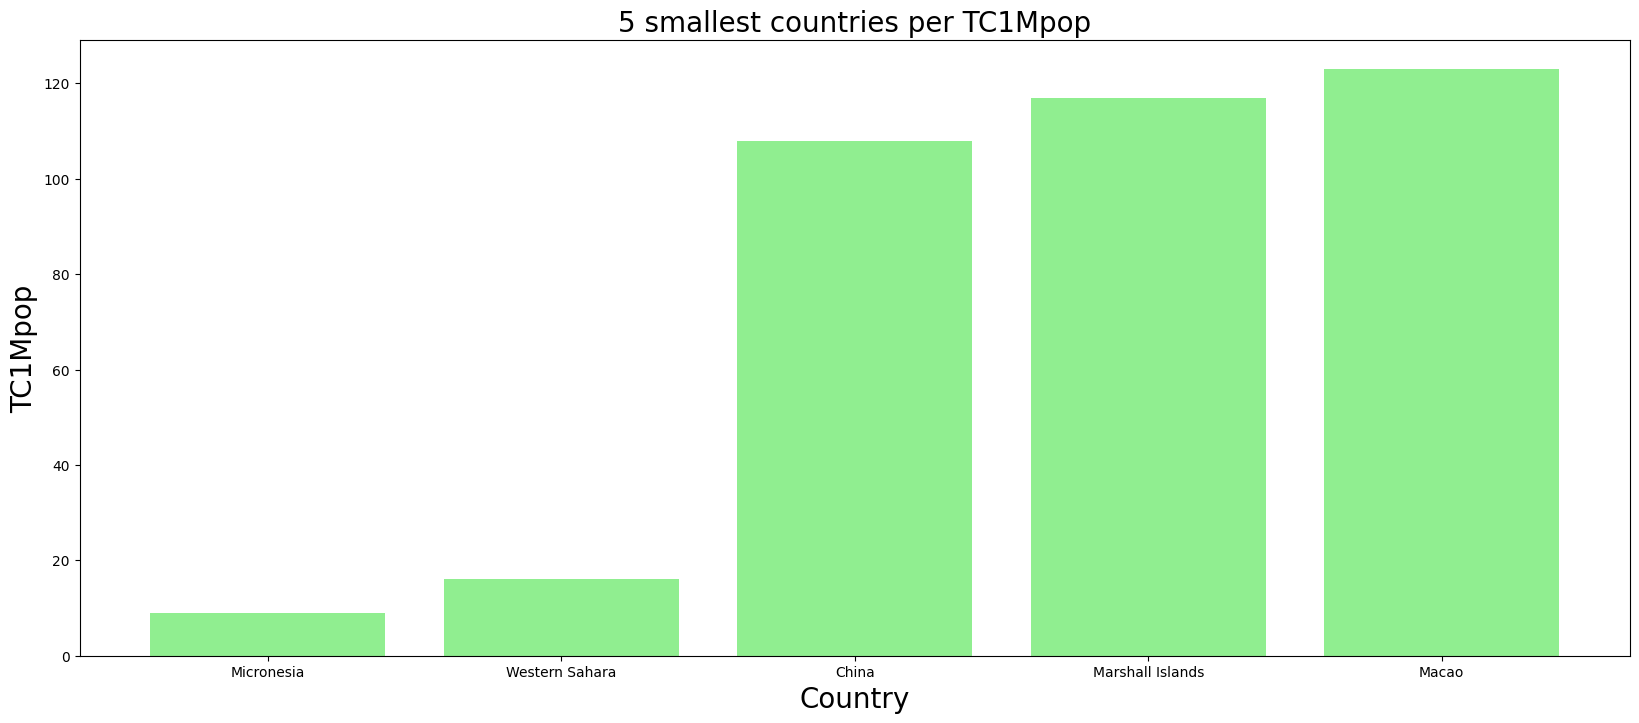

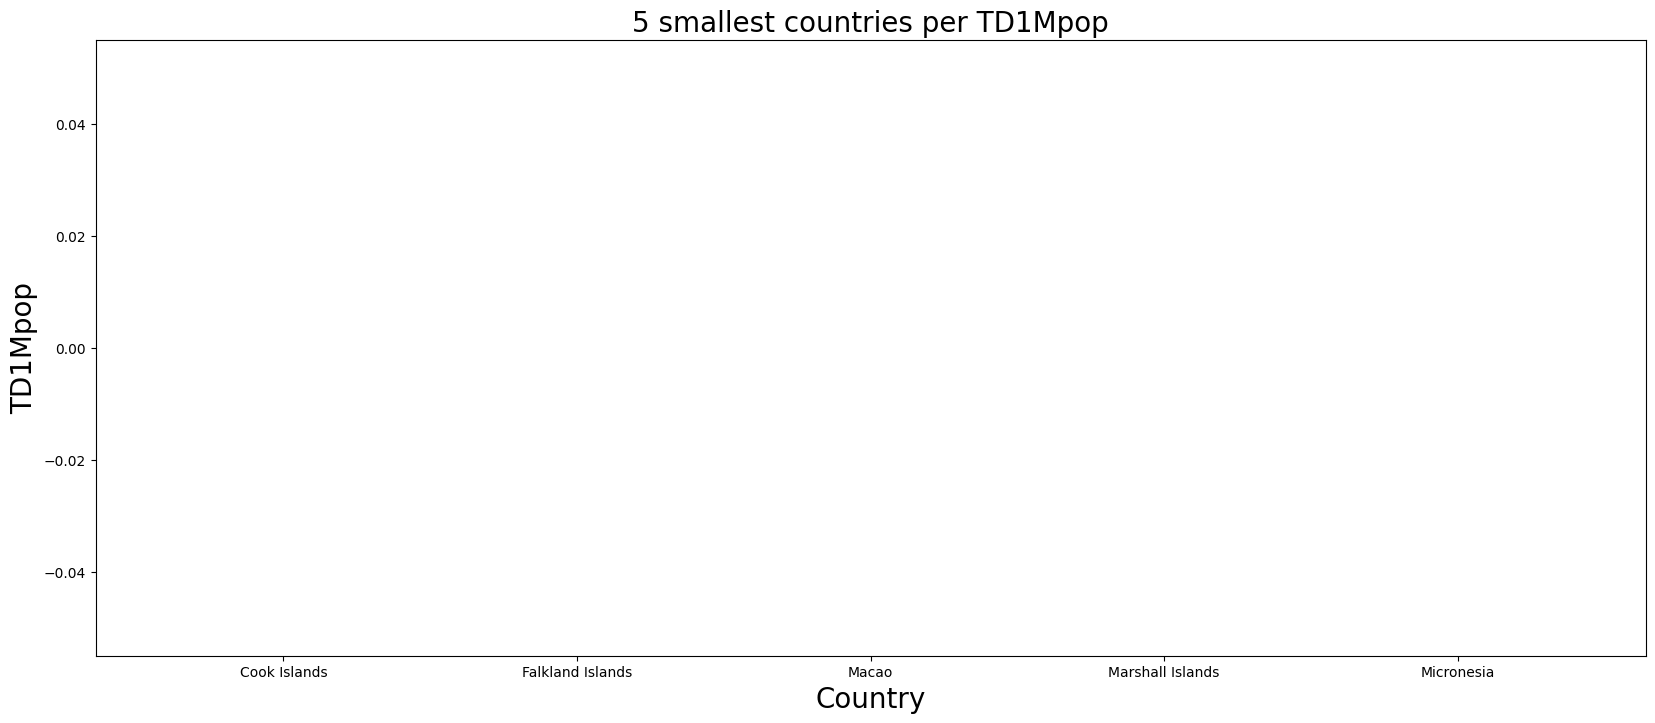

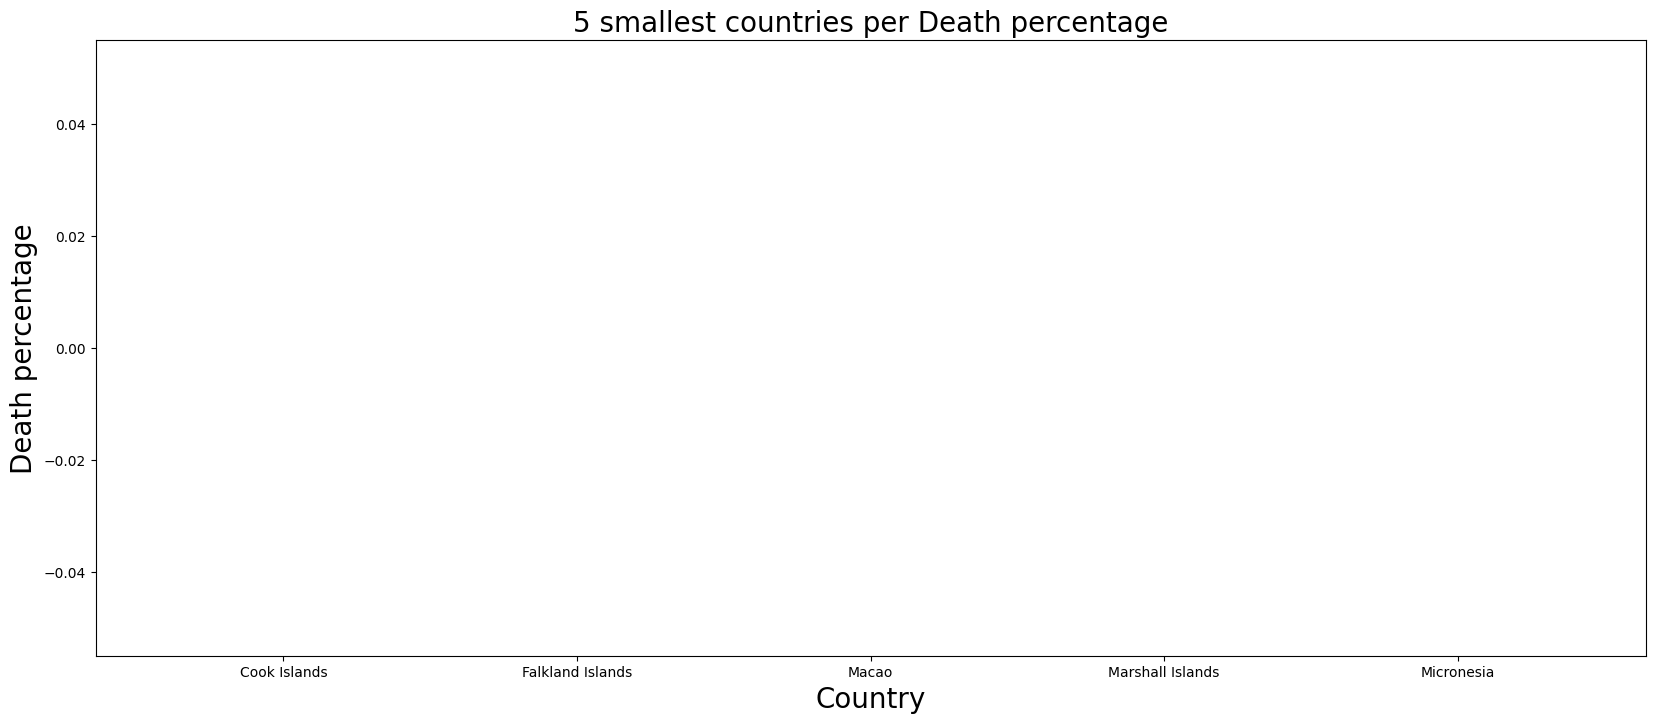

In [14]:
for column in columns:
  top5 = df.nsmallest(5,column)
  plt.figure(figsize=(20,8))
  plt.bar(top5['Country'], top5[column],color="lightgreen",alpha=1)
  plt.ylabel(column, fontsize = 20)
  plt.xlabel("Country", fontsize = 20)
  plt.title(f"5 smallest countries per {column}", fontsize = 20)
  plt.show()

* Diskussion

## Beschränkun auf Europa

In [15]:
Europe=df[df['Continent']=='Europe']

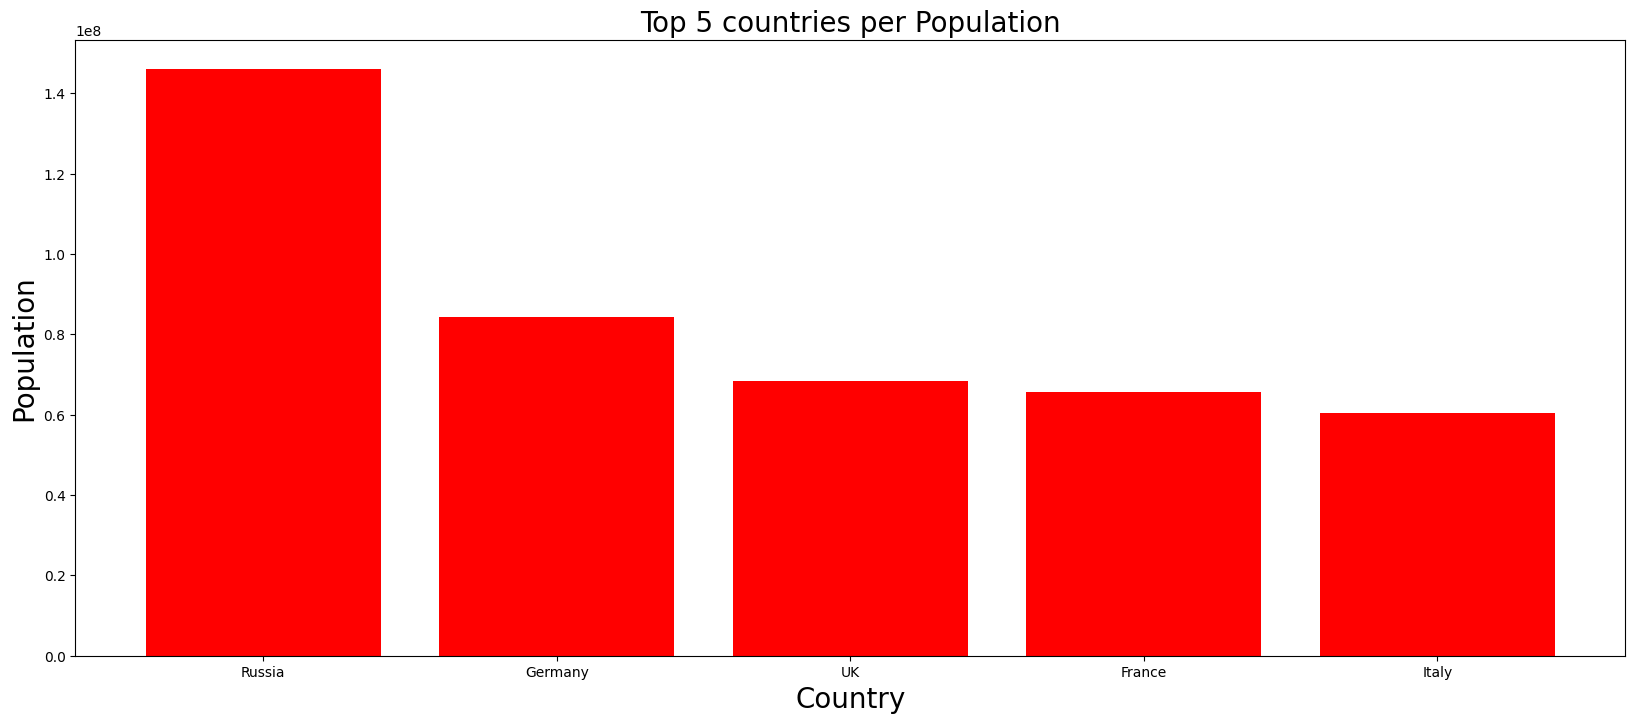

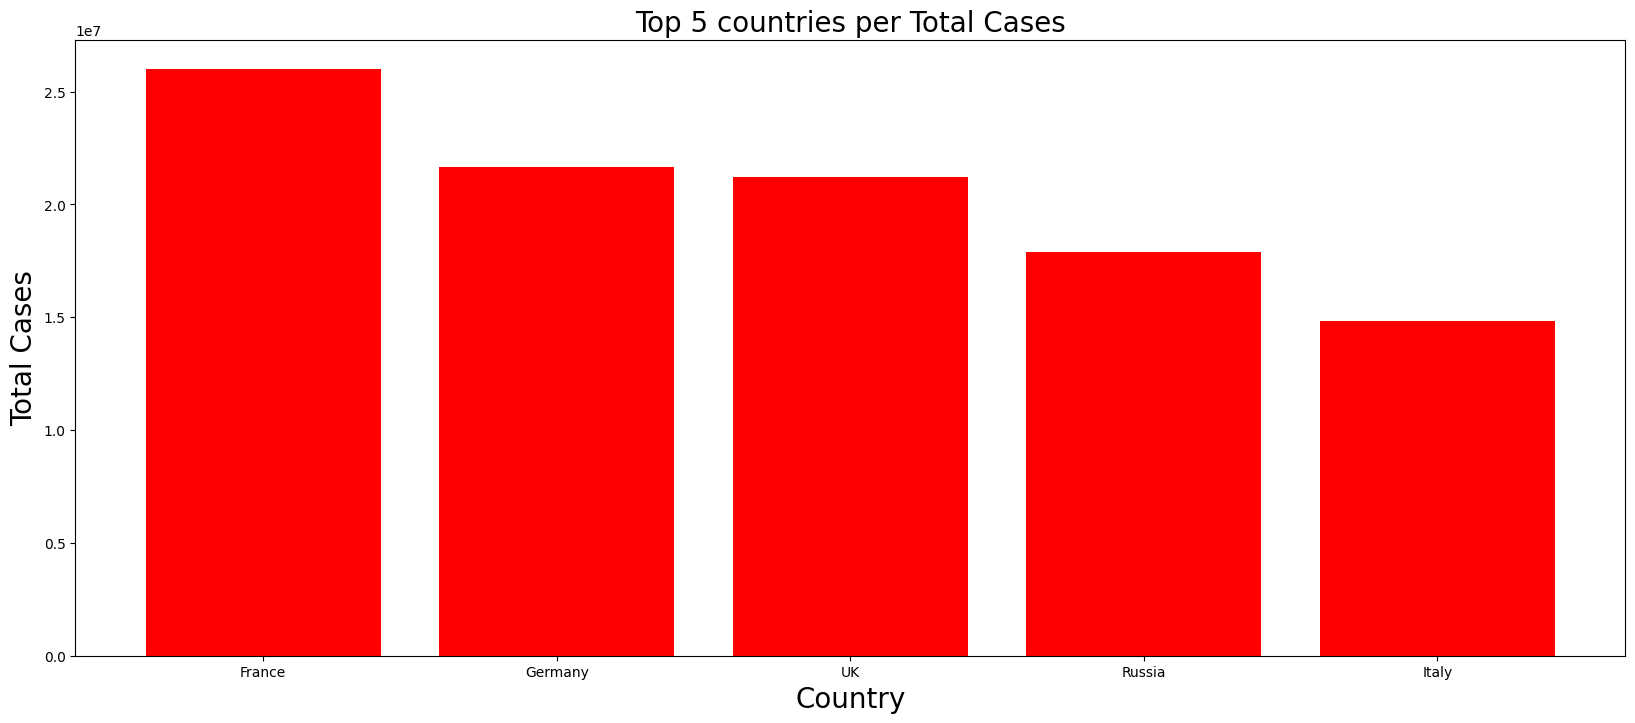

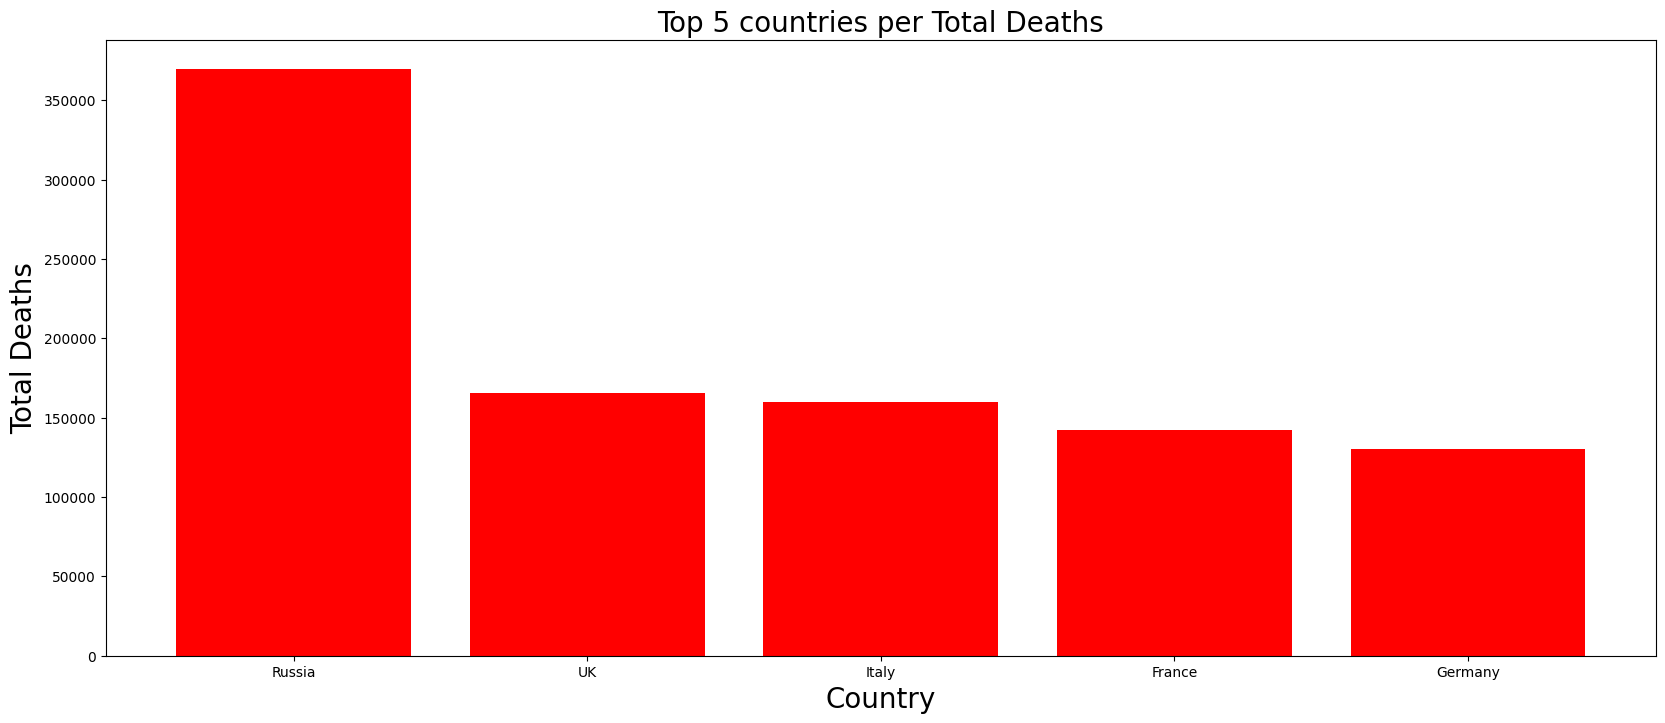

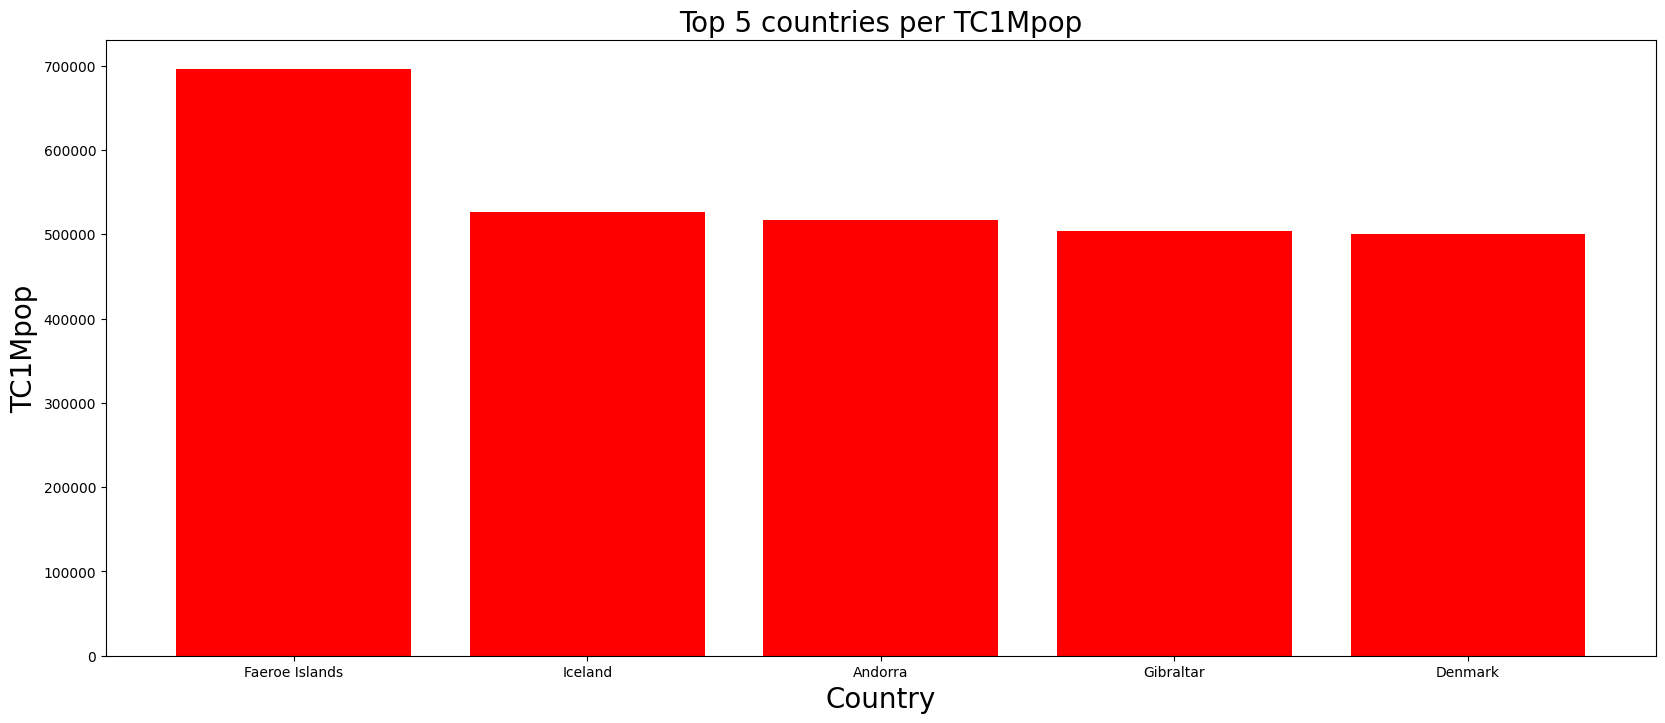

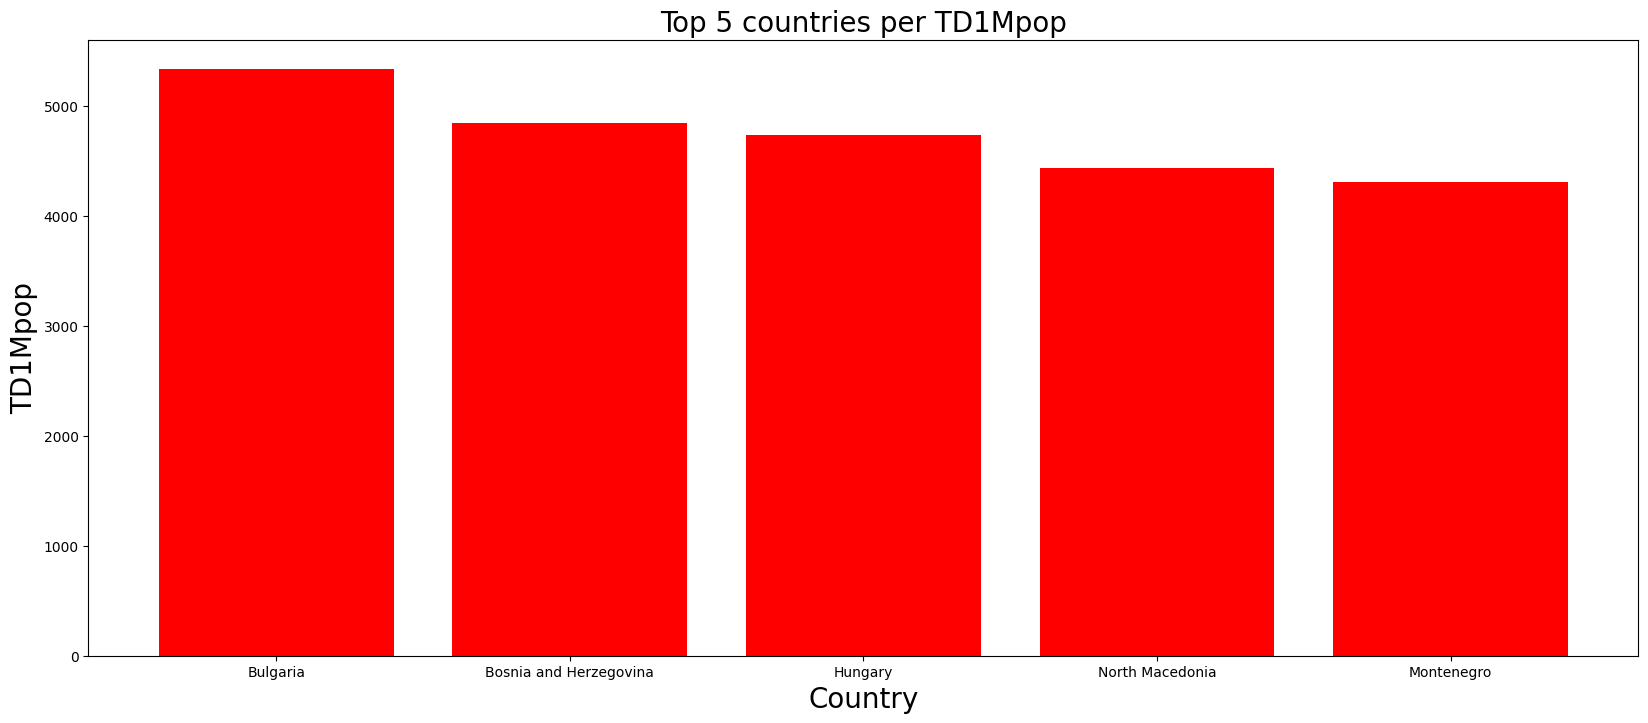

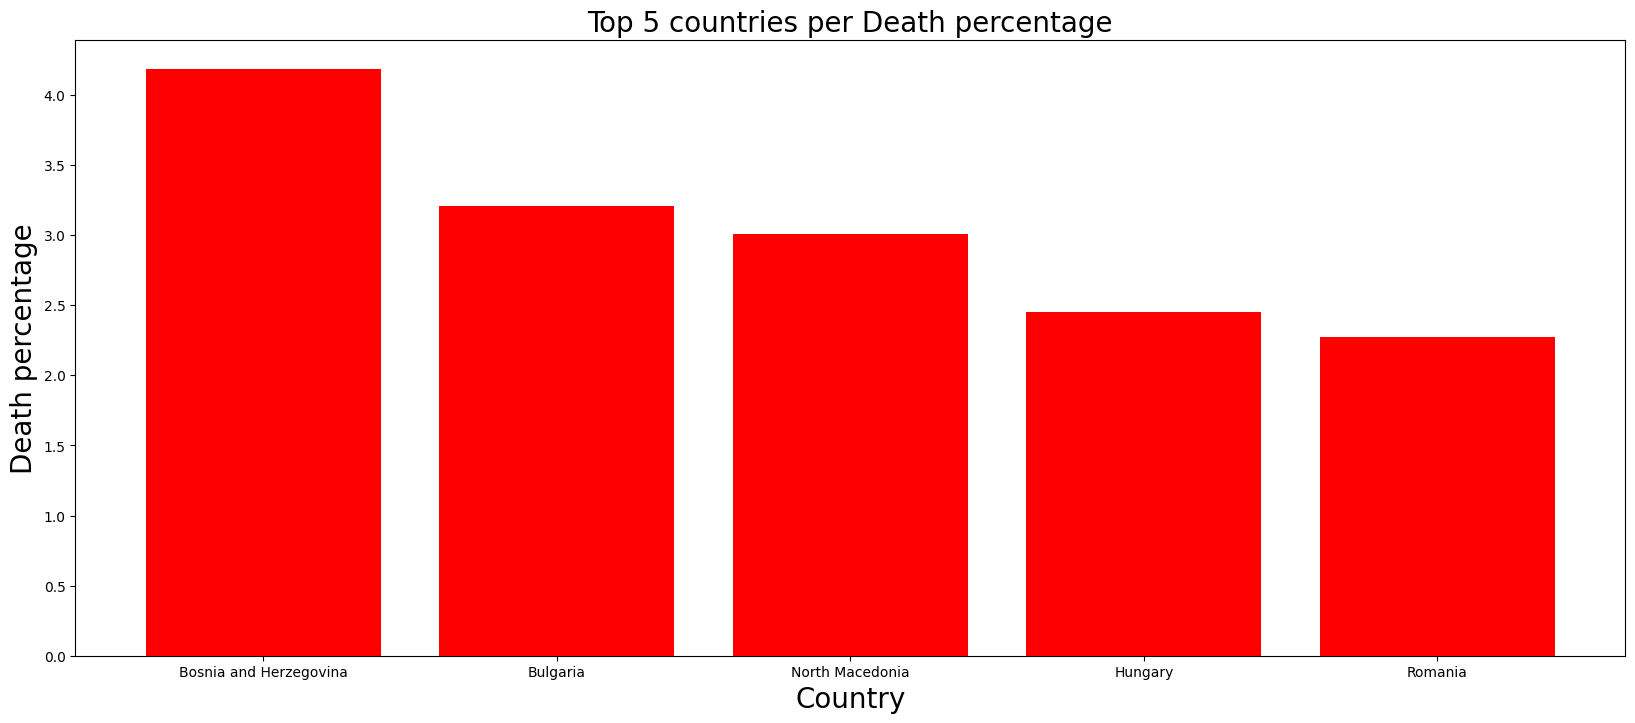

In [16]:
for column in columns:
  top5 = Europe.nlargest(5,column)
  plt.figure(figsize=(20,8))
  plt.bar(top5['Country'], top5[column],color="red",alpha=1)
  plt.ylabel(column, fontsize = 20)
  plt.xlabel("Country", fontsize = 20)
  plt.title(f"Top 5 countries per {column}", fontsize = 20)
  plt.show()

* Diskussion

## Ausreisser

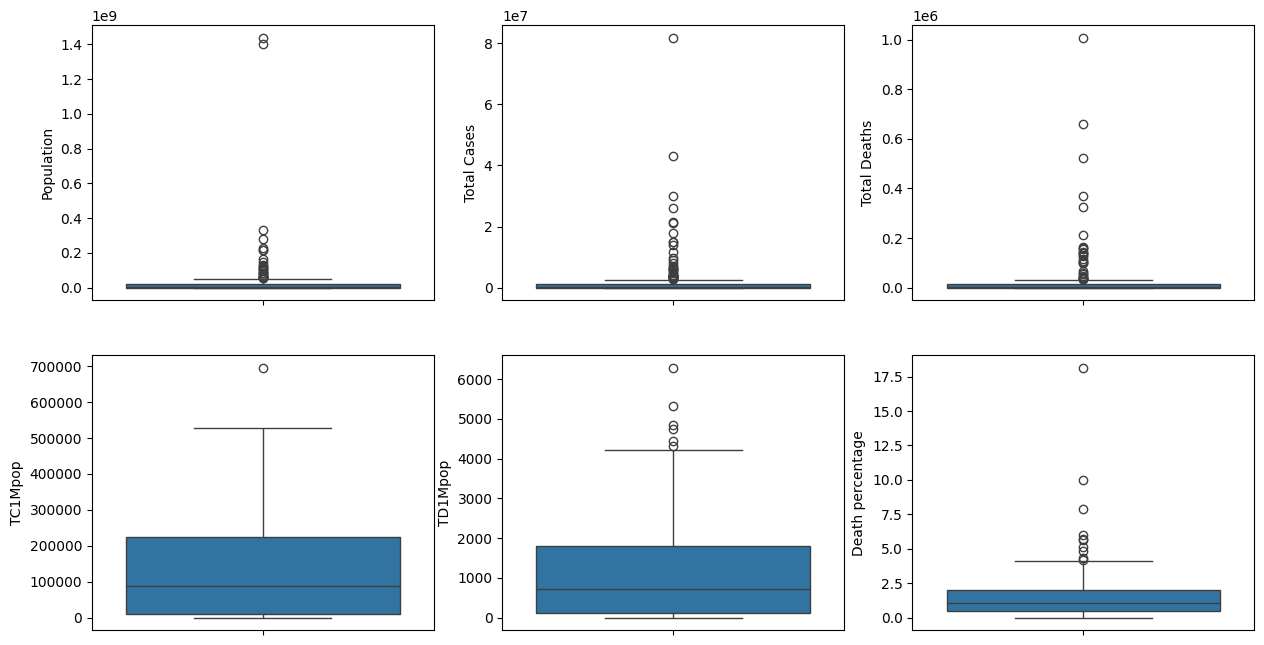

In [17]:
i=1
plt.figure(figsize=(15,25))
for feature in columns:
    plt.subplot(6,3,i)
    sns.boxplot(y=df[feature])
    i+=1
    

* Diskussion

### Korrelation

In [18]:
correlation = df[columns].corr()
print(correlation['TD1Mpop'].sort_values(ascending = False),'\n')


TD1Mpop             1.000000
TC1Mpop             0.508630
Total Deaths        0.289201
Total Cases         0.216272
Death percentage    0.061088
Population         -0.066485
Name: TD1Mpop, dtype: float64 



Index(['TD1Mpop', 'TC1Mpop', 'Total Deaths', 'Total Cases', 'Death percentage',
       'Population'],
      dtype='object')


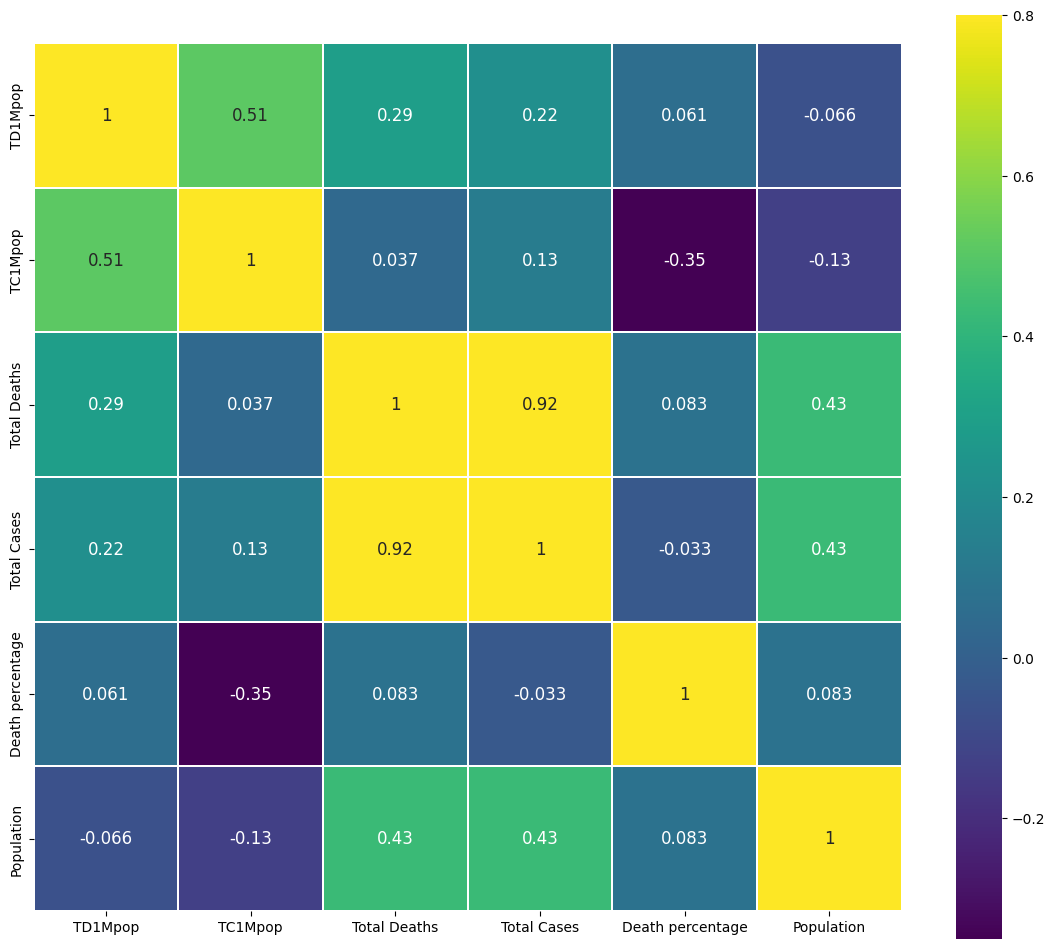

In [19]:
k= 10
cols = correlation.nlargest(k,'TD1Mpop')['TD1Mpop'].index
print(cols)
cm = np.corrcoef(df[cols].values.T)
f , ax = plt.subplots(figsize = (14,12))
sns.heatmap(cm, vmax=.8, linewidths=0.01,square=True,annot=True,cmap='viridis',
            linecolor="white",xticklabels = cols.values ,annot_kws = {'size':12},yticklabels = cols.values)
plt.show()

* Diskussion